# 06: Shor's Algorithm — Circuit Implementation

We implement the quantum circuit from note `06_shor_algorithm.md` in Qiskit and verify the prime factorization of $N = 15$, $a = 7$ by simulation.

**Contents:**
1. Verifying the modular multiplication $U_7$
2. Building and running the Shor QPE circuit
3. Recovering the order $r$ from the measurement result (continued fraction expansion)

> **Notation note:** The notes and Qiskit differ in the starting index (1 vs 0) and the bit order in ket notation. See [01_qubit_ordering.ipynb](01_qubit_ordering.ipynb) for details. The physical results are not affected.

In [17]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate
import numpy as np
from math import gcd
from fractions import Fraction

**Import explanation:**

- `QuantumCircuit`, `QuantumRegister`, `ClassicalRegister`: For building quantum circuits (see notebook 03).
- `Statevector`, `Operator`: For state vector simulation and unitary matrix manipulation (see notebook 05).
- `QFTGate`: The Quantum Fourier Transform gate. `QFTGate(n).inverse()` generates the inverse QFT.
- `gcd` (math): Greatest common divisor. Used for computing $\gcd(a, N)$ and extracting prime factors.
- `Fraction` (fractions): A class for handling rational numbers. `.limit_denominator(N)` is used to find the convergents of the continued fraction expansion.

## 1. Verifying the Modular Multiplication $U_a$

Verify $U_a|x\rangle = |ax \bmod N\rangle$. For $a = 7$, $N = 15$:

$$
|1\rangle \to |7\rangle \to |4\rangle \to |13\rangle \to |1\rangle
$$

It cycles with period $r = 4$.

In [ ]:
a = 7
N = 15

# Verify the cycle of U_a
print(f"a = {a}, N = {N}")
print(f"gcd({a}, {N}) = {gcd(a, N)} → coprime\n")

x = 1
print(f"Cycle of U_a (starting from |1⟩):")
for k in range(5):
    print(f"  U_a^{k}|1⟩ = |{a}^{k} mod {N}⟩ = |{pow(a, k, N)}⟩")

# Verify the order r
r = 1
while pow(a, r, N) != 1:
    r += 1
print(f"\nOrder r = {r} ({a}^{r} mod {N} = {pow(a, r, N)})")

**Code explanation:**

- `gcd(a, N)`: Computes the greatest common divisor of $a$ and $N$. Since $\gcd(7, 15) = 1$, they are coprime, and we can proceed to order finding.
- `pow(a, k, N)`: Efficiently computes $a^k \bmod N$. A built-in Python function that performs modular exponentiation when given a third argument. Does not overflow even for large numbers.

### Pre-computing Controlled $U_a^{2^k}$

QPE requires controlled $U_a^{2^k}$. Pre-compute $7^{2^k} \bmod 15$.

In [ ]:
print("Powers of U_a needed for QPE:")
for k in range(4):
    power = 2 ** k
    val = pow(a, power, N)
    print(f"  7^{power} mod 15 = {val}  →  U_a^{power}|x⟩ = |{val}·x mod 15⟩")

## 2. Shor's QPE Circuit

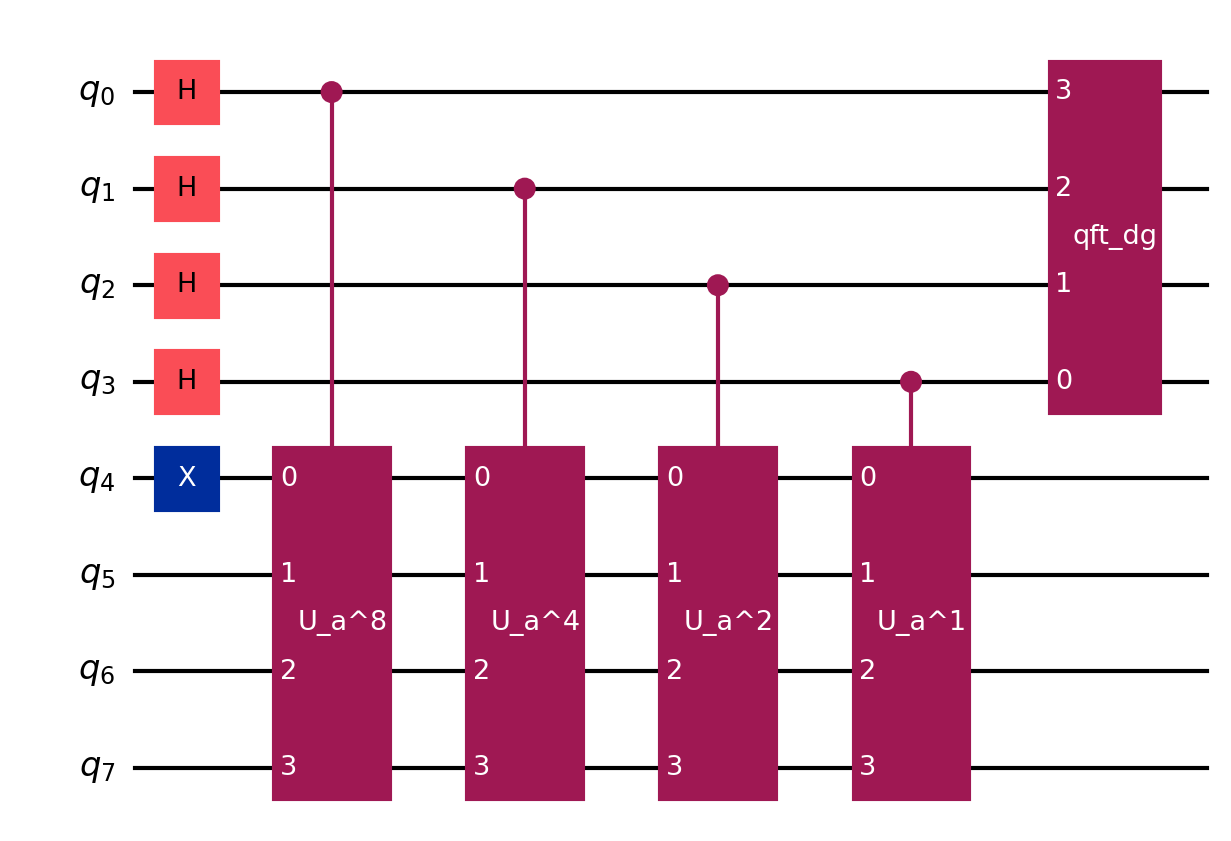

Since $N = 15$, the work register has $L = \lceil\log_2 15\rceil = 4$ qubits.
The counting register also has $n = 4$ bits.

We build $U_a|x\rangle = |ax \bmod N\rangle$ directly as a unitary matrix (matrix representation is feasible since $N = 15$ is small).

In [ ]:
def modular_mult_gate(a, N, n_qubits):
    """Build the unitary matrix for U_a|x⟩ = |a*x mod N⟩.
    
    For x < N, maps to |a*x mod N⟩.
    For x >= N, leaves it as |x⟩ (identity). Padding to preserve unitarity.
    """
    dim = 2 ** n_qubits
    U = np.zeros((dim, dim), dtype=complex)
    for x in range(dim):
        if x < N:
            y = (a * x) % N
        else:
            y = x  # identity: not used in actual computation
        U[y, x] = 1
    return U


# Build the matrix for U_7
L = 4  # number of bits in the work register (q_4 to q_7 in the circuit)
U7_matrix = modular_mult_gate(7, 15, L)

# Verify: |1⟩ → |7⟩, |7⟩ → |4⟩, |4⟩ → |13⟩, |13⟩ → |1⟩
print("U_7 verification:")
for x in [1, 7, 4, 13, 2, 3]:
    state = np.zeros(2**L)
    state[x] = 1
    result = U7_matrix @ state
    y = np.argmax(np.abs(result))
    print(f"  U_7|{x}⟩ = |{y}⟩  (7×{x} mod 15 = {(7*x)%15})")

**Code explanation:**

`modular_mult_gate(a, N, n_qubits)`:
- Directly builds the unitary matrix for $U_a\vert x\rangle = \vert ax \bmod N\rangle$ as a $2^n \times 2^n$ matrix. Practical only for small numbers like $N = 15$.
- `U[y, x] = 1`: Indicates that the column vector $\vert x\rangle$ maps to the row vector $\vert y\rangle$. The $(y, x)$ entry of the matrix is 1.
- Excess states with $x \ge N$ are treated as identity ($\vert x\rangle \to \vert x\rangle$). The quantum register has $2^L$ basis states but uses only $N$ of them.

`np.argmax(np.abs(result))`: Returns the index with the maximum amplitude in the result vector. Since this is a mapping between computational basis states, only one component has amplitude 1.

In [ ]:
def shor_qpe_circuit(a, N, n_counting, n_work):
    """Build the QPE circuit for Shor's algorithm (no measurement).
    
    a: base
    N: number to factorize
    n_counting: number of bits in the counting register
    n_work: number of bits in the work register
    """
    n_total = n_counting + n_work
    qc = QuantumCircuit(n_total)

    # Initialize work register to |1⟩
    # |1⟩ = |0001⟩ → set the LSB (qubit n_counting) to 1
    # In Qiskit's little-endian, qubit n_counting is work_0 (LSB)
    qc.x(n_counting)

    # Step 1: Hadamard on the counting register
    for i in range(n_counting):
        qc.h(i)

    # Step 2: Controlled modular multiplication
    # counting_k (k=0 is MSB) controls U_a^{2^{n-1-k}}
    for k in range(n_counting):
        power = 2 ** (n_counting - 1 - k)
        # Matrix for U_a^power
        a_power = pow(a, power, N)
        U_matrix = modular_mult_gate(a_power, N, n_work)
        U_gate = QuantumCircuit(n_work, name=f"U_a^{power}")
        U_gate.unitary(Operator(U_matrix), range(n_work))
        c_U = U_gate.to_gate().control(1)
        qc.append(c_U, [k] + list(range(n_counting, n_total)))

    # Step 3: Inverse QFT
    # QFTGate(n).inverse() gives the n-bit inverse QFT.
    # However, QFTGate treats qubit 0 as the LSB on append.
    # In this circuit qubit 0 is the MSB, so pass the qubits in reverse order.
    # Example: for n_counting=4, list(range(3, -1, -1)) = [3, 2, 1, 0]
    qft_inv = QFTGate(n_counting).inverse()
    counting_qubits_reversed = list(range(n_counting - 1, -1, -1))
    qc.append(qft_inv, counting_qubits_reversed)

    return qc


# Build the circuit
n_counting = 4
n_work = 4
qc_shor = shor_qpe_circuit(7, 15, n_counting, n_work)
print(f"Shor QPE circuit: {qc_shor.num_qubits} qubits (counting {n_counting} + work {n_work})")

**Code explanation:**

`shor_qpe_circuit(a, N, n_counting, n_work)`:
- `qc.x(n_counting)`: Sets the LSB of the work register (Qiskit's $q_{n\_counting}$) to $\vert 1\rangle$. The work register as a whole represents the integer $\vert 1\rangle$.
- `pow(a, power, N)`: Computes $a^{2^k} \bmod N$. Since $U_a^{2^k}\vert x\rangle = \vert a^{2^k} x \bmod N\rangle$, we use this as a new base to build the modular multiplication matrix.
- `U_gate.unitary(Operator(U_matrix), range(n_work))`: Incorporates the NumPy matrix `U_matrix` as a Qiskit unitary gate into the circuit. Wrapping with `Operator` is required.
- `.to_gate().control(1)`: Adds a control bit to the constructed gate.
- `qc.append(c_U, [k] + list(range(...)))`: Specifies the control bit `k` (counting register) and target bits (entire work register) and applies the gate.

### Running QPE and Measurement Results

Compute the measurement probabilities of the counting register via state vector simulation.

As explained in Note 06, for each eigenvector $\ell = 0, 1, 2, 3$, we expect $s = 0, 4, 8, 12$ to be obtained with probability $1/4$ each.

In [ ]:
# Get the state vector
sv = Statevector.from_instruction(qc_shor)

# Compute the measurement probabilities of the counting register
probs_counting = {}
for i, amp in enumerate(sv):
    prob = abs(amp) ** 2
    if prob > 1e-12:
        # Get the bits of the counting register (qubit 0 to 3)
        counting_bits = []
        for k in range(n_counting):
            counting_bits.append((i >> k) & 1)
        # counting_0 (qubit 0) is MSB
        s = sum(counting_bits[k] * 2 ** (n_counting - 1 - k) for k in range(n_counting))
        if s not in probs_counting:
            probs_counting[s] = 0.0
        probs_counting[s] += prob

N_qpe = 2 ** n_counting
print(f"Shor QPE measurement results (a={a}, N={N}, n={n_counting})")
print(f"{'s':>5}  {'s/2^n':>10}  {'probability':>12}  {'corresponding ℓ'}")
print("-" * 50)
for s in sorted(probs_counting.keys()):
    p = probs_counting[s]
    phase = s / N_qpe
    # Estimate the corresponding ℓ
    ell_val = round(phase * 4)  # assume r=4 (for verification)
    print(f"{s:5d}  {phase:10.4f}  {p:12.4f}  ℓ = {ell_val}")

## 3. Recovering the Order $r$ from Measurement Results (Continued Fraction Expansion)

The observer only gets the integer $s$; $\ell$ and $r$ are not directly known.
Continued-fraction-expand $s/2^n$ and find candidates for $r$ from the denominators of the convergents.

In [ ]:
def find_order(s, n_counting, a, N):
    """Find a candidate for the order r from the measurement result s.
    
    Approximate s/2^n as a rational number, taking the denominator as a candidate for r.
    Returns None if not found.
    """
    if s == 0:
        return None
    
    # Best rational approximation of s/2^n (denominator < N)
    frac = Fraction(s, 2 ** n_counting).limit_denominator(N)
    r = frac.denominator
    
    # Verify whether r is the order (correct if a^r mod N = 1)
    if pow(a, r, N) == 1 and r > 1:
        return r
    
    # If reduction hides the true order, try small multiples
    for mult in range(2, 5):
        if pow(a, r * mult, N) == 1:
            return r * mult
    
    return None


# For each measurement result, find the order
print("Estimating the order r from measurement results:")
print(f"{'s':>5}  {'s/2^n':>10}  {'approx frac':>12}  {'r':>5}  {'verification'}")
print("-" * 55)
for s in sorted(probs_counting.keys()):
    if probs_counting[s] < 0.01:
        continue
    frac = Fraction(s, 2 ** n_counting).limit_denominator(N)
    r = find_order(s, n_counting, 7, 15)
    check = f"7^{r} mod 15 = {pow(7, r, 15)}" if r else "—"
    print(f"{s:5d}  {s/16:10.4f}  {str(frac):>12}  {str(r):>5}  {check}")

**Code explanation:**

- `Fraction(s, 2**n_counting).limit_denominator(N)`: Approximates $s/2^n$ as a rational number with denominator less than $N$. Internally uses continued fraction expansion, and the denominator becomes a candidate for the order $r$.
- `pow(a, r, N) == 1`: Verifies the candidate $r$. If $a^r \bmod N = 1$, $r$ is correct as the order.
- We try multiples because, when $\ell$ and $r$ have a common factor (e.g., $\ell/r = 2/4$ reduces to $1/2$), the true $r$ does not appear in the denominator.